In [1]:
!pip install pyreadstat
!pip install scikeras tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.7/617.7 kB 11.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


2025-06-16 14:19:26.061978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750083566.285606      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750083566.351412      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# EDA

In [29]:
df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')

# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,6.9,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,10.5,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0
7,1.0,10.4,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
10,1.0,8.8,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1.0,1
13,1.0,9.7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
15,1.0,10.3,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
16,1.0,7.7,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1


In [32]:
#Scaling child weight
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

In [33]:
df2.head()

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,-0.617934,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,0.797956,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,0.025652,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,-1.004086,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,0.540522,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0


In [34]:
# # Label/one-hot-encoding for Ordinal/nominal features
# le = LabelEncoder()
# df2['mother_education'] = le.fit_transform(df2['mother_education'])
# df2['wealth_index'] = le.fit_transform(df2['wealth_index'])
# df2 = pd.get_dummies(df2, columns = ['province'])
# df = df2.astype(int)
# df.head(10)

# Artificial Neural Network

In [40]:
from kerastuner.tuners import RandomSearch
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [44]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['recall'])

# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  
    epochs=100,            
    batch_size=16,
    # callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7301 - recall: 0.6309 - val_loss: 0.6753 - val_recall: 0.1916
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6715 - recall: 0.3192 - val_loss: 0.6538 - val_recall: 0.4598
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6468 - recall: 0.5455 - val_loss: 0.6484 - val_recall: 0.4943
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6592 - recall: 0.5395 - val_loss: 0.6487 - val_recall: 0.4291
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6459 - recall: 0.4718 - val_loss: 0.6425 - val_recall: 0.4713
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6338 - recall: 0.5420 - val_loss: 0.6459 - val_recall: 0.3985
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6353 - recall: 0.5174 - val_loss: 0.6407 - val_recall: 0.5057
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6310 - recall: 0.4814 - val_loss: 0.6414 - val_recall: 0.4330

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# 🧠 Model builder function
def create_model(units=32, num_hidden_layers=1, dropout_rate=0.2,
                 learning_rate=0.001, use_batchnorm=False):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(units, activation='relu'))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    for _ in range(num_hidden_layers - 1):
        model.add(Dense(units, activation='relu'))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['Recall']
    )
    return model

# 🔧 Wrap in Scikeras KerasClassifier
model = KerasClassifier(model=create_model, verbose=0)

# 🧪 Define hyperparameter space
param_dist = {
    'model__units': [32, 64, 128],
    'model__num_hidden_layers': [1, 2, 3],
    'model__dropout_rate': [0.2, 0.3, 0.4],
    'model__learning_rate': [1e-2, 1e-3, 1e-4],
    'model__use_batchnorm': [True, False],
    'batch_size': [32, 64],
    'epochs': [30, 50]
}

# 🎯 Randomized search with 5-fold CV optimizing for recall
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=1
)

# 🚀 Run the search
search.fit(X_train, y_train)

# 🥇 Best model and parameters
print("Best Recall:", search.best_score_)
print("Best Params:", search.best_params_)

# You can now use the best model:
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Recall: 0.6872794117647059
Best Params: {'model__use_batchnorm': True, 'model__units': 128, 'model__num_hidden_layers': 3, 'model__learning_rate': 0.01, 'model__dropout_rate': 0.4, 'epochs': 50, 'batch_size': 32}


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall

# Define the model using the best hyperparameters
def create_best_model(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # First hidden layer
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())  # use_batchnorm = True
    model.add(Dropout(0.4))

    # Second hidden layer
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    # Third hidden layer
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss=BinaryCrossentropy(),
        metrics=[Recall()]
    )

    return model

# Example usage
model = create_best_model(input_dim=X_train.shape[1])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]  # if you’ve defined EarlyStopping already
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.9035 - recall_406: 0.4626 - val_loss: 0.6641 - val_recall_406: 0.0881
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6662 - recall_406: 0.4979 - val_loss: 0.6836 - val_recall_406: 0.1456
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6680 - recall_406: 0.4529 - val_loss: 0.6560 - val_recall_406: 0.3448
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6406 - recall_406: 0.4951 - val_loss: 0.6487 - val_recall_406: 0.3985
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6578 - recall_406: 0.5250 - val_loss: 0.6568 - val_recall_406: 0.6169
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6489 - recall_406: 0.5285 - val_loss: 0.6390 - val_recall_406: 0.5019
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6197 - recall_406: 0.6054 - val_loss: 0.6453 - val_recall_406: 0.4674
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6463 - recall_406: 0.4536 - v

In [70]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_hidden', min_value=8, max_value=64, step=8),
        activation='relu'
    ))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-1, 1e-2, 1e-3, 1e-4])),
        loss=BinaryCrossentropy(),
        metrics=[Recall()]
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


tuner = RandomSearch(
    build_model,
    objective='val_recall',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='binary_class_tuning'
)

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stop])
best_model = tuner.get_best_models(num_models=1)[0]

Reloading Tuner from tuner_dir/binary_class_tuning/tuner0.json


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [71]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(f"Input layer units: {best_hps.get('units_input')}")
print(f"Hidden layer units: {best_hps.get('units_hidden')}")
print(f"Dropout rate: {best_hps.get('dropout')}")
print(f"Learning rate: {best_hps.get('lr')}")


Best hyperparameters:
Input layer units: 48
Hidden layer units: 40
Dropout rate: 0.4
Learning rate: 0.1


In [72]:
best_model = build_model(best_hps)
best_model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stop])


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.7642 - recall_1: 0.2191 - val_loss: 0.6638 - val_recall_1: 0.2414
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6798 - recall_1: 0.4596 - val_loss: 0.6591 - val_recall_1: 0.4866
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6822 - recall_1: 0.4135 - val_loss: 0.6909 - val_recall_1: 0.0000e+00
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6842 - recall_1: 0.0110 - val_loss: 0.6904 - val_recall_1: 0.0000e+00
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6906 - recall_1: 0.0000e+00 - val_loss: 0.6926 - val_recall_1: 0.0000e+00
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6930 - recall_1: 0.0000e+00 - val_loss: 0.6904 - val_recall_1: 0.0000e+00
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6851 - recall_1: 0.0000e+00 - val_loss: 0.7017 - val_recall_1: 0.0000e+00
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6852 - recall_1: 

In [73]:
y_pred_probs = best_model.predict(X_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.65      0.72      0.68       397
           1       0.59      0.51      0.55       320

    accuracy                           0.63       717
   macro avg       0.62      0.61      0.61       717
weighted avg       0.62      0.63      0.62       717



In [74]:
# Get predicted probabilities
y_probs = model.predict(X_test)

# Convert to class labels
y_pred = (y_probs > 0.5).astype("int")

# Print classification report
print(classification_report(y_test, y_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.73      0.65      0.69       397
           1       0.62      0.69      0.65       320

    accuracy                           0.67       717
   macro avg       0.67      0.67      0.67       717
weighted avg       0.68      0.67      0.67       717



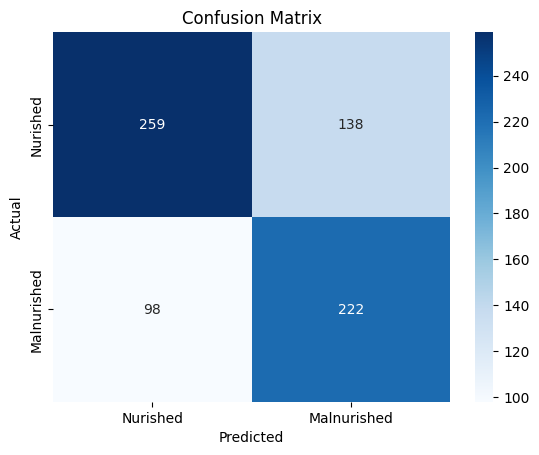

In [67]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [68]:
# Use model.predict() and flatten to 1D
y_probas = model.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.6553718401349148


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


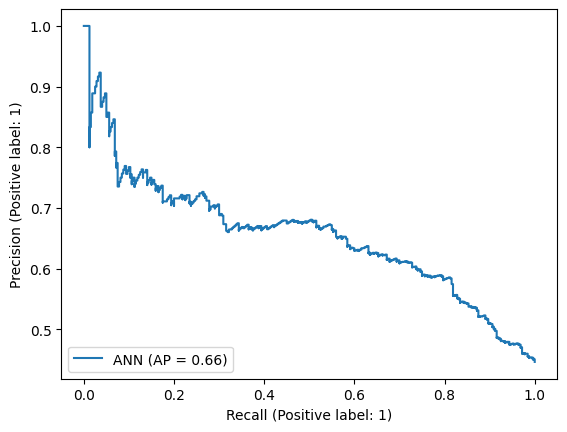

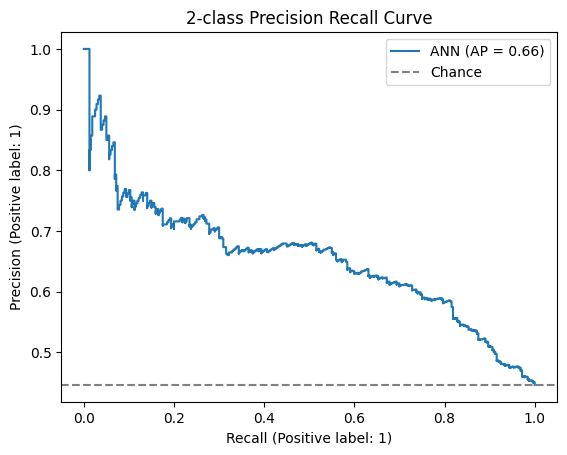

In [69]:
# Get predicted probabilities
y_probas = model.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()
